In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [119]:
# 2. paths
import os

base = '/content/drive/MyDrive/ONCO-PROBE'
data = os.path.join(base, 'data')

results = os.path.join(base, 'results_v2')
figures = os.path.join(results, 'figures')
processed = os.path.join(results, 'processed')
validation = os.path.join(results, 'validation')

models_dir = os.path.join(base, 'models_v2')
models_img = os.path.join(models_dir, 'image_classifier')
models_gene = os.path.join(models_dir, 'gene_classifier')

sensitivity = os.path.join(base, 'sensitivity_maps_v2')
img_maps = os.path.join(sensitivity, 'image_maps')
gene_maps = os.path.join(sensitivity, 'gene_maps')

for folder in [results, figures, processed, validation,
               models_dir, models_img, models_gene,
               sensitivity, img_maps, gene_maps]:
    os.makedirs(folder, exist_ok=True)

print("All folders created")
print("Base:", base)
print("Results:", results)

All folders created
Base: /content/drive/MyDrive/ONCO-PROBE
Results: /content/drive/MyDrive/ONCO-PROBE/results_v2


In [3]:
# 3. install
!pip install openpyxl pandas numpy matplotlib seaborn scikit-learn pillow pycomba

ERROR: Could not find a version that satisfies the requirement pycomba (from versions: none)
ERROR: No matching distribution found for pycomba


In [120]:
# 4. imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import zipfile
import warnings
warnings.filterwarnings('ignore')

print("Imports done")

Imports done


In [ ]:
# 5. extract A2 images
zip_a2 = os.path.join(data, 'TCGA-BRCA-A2-DEEPMED-TILES.zip')
extract_a2 = os.path.join(data, 'tcga_images_a2')

if not os.path.exists(extract_a2):
    os.makedirs(extract_a2, exist_ok=True)
    with zipfile.ZipFile(zip_a2, 'r') as z:
        z.extractall(extract_a2)
    print("A2 images extracted")
else:
    print("A2 already extracted")

A2 images extracted


In [137]:
# verify A2 extraction
import os

extract_a2 = os.path.join(data, 'tcga_images_a2')

total_files = 0
for root, dirs, files in os.walk(extract_a2):
    total_files += len(files)

print("A2 files in Drive:", total_files)
print("Expected: around 268938")

A2 files in Drive: 268938
Expected: around 268938


In [ ]:
# 6. extract E2 images separately
zip_e2 = os.path.join(data, 'TCGA-BRCA-E2-DEEPMED-TILES.zip')
extract_e2 = os.path.join(data, 'tcga_images_e2')

if not os.path.exists(extract_e2):
    os.makedirs(extract_e2, exist_ok=True)
    with zipfile.ZipFile(zip_e2, 'r') as z:
        z.extractall(extract_e2)
    print("E2 images extracted")
else:
    print("E2 already extracted")

E2 images extracted


In [138]:
# check E2 in drive
import os

extract_e2 = '/content/drive/MyDrive/ONCO-PROBE/data/tcga_images_e2'

total = 0
for root, dirs, files in os.walk(extract_e2):
    total += len(files)

print("E2 files in Drive:", total)
print("Expected: around 214210")

E2 files in Drive: 41061
Expected: around 214210


In [121]:
# 7. count images
a2_files = []
for root, dirs, files in os.walk(extract_a2):
    for f in files:
        if f.endswith('.jpg') or f.endswith('.png'):
            a2_files.append(os.path.join(root, f))

e2_files = []
for root, dirs, files in os.walk(extract_e2):
    for f in files:
        if f.endswith('.jpg') or f.endswith('.png'):
            e2_files.append(os.path.join(root, f))

print("A2 images:", len(a2_files))
print("E2 images:", len(e2_files))
print("E2 is set aside for external validation only")

A2 images: 268938
E2 images: 41061
E2 is set aside for external validation only


In [122]:
# 8. load A2 clinical
clini_a2 = pd.read_excel(os.path.join(data, 'TCGA-BRCA-A2-CLINI.xlsx'))
slide_a2 = pd.read_excel(os.path.join(data, 'TCGA-BRCA-A2_SLIDE.xlsx'))

print("A2 clinical:", clini_a2.shape)
print("A2 slide:", slide_a2.shape)

A2 clinical: (102, 203)
A2 slide: (100, 2)


In [123]:
# 9. load E2 clinical
clini_e2 = pd.read_excel(os.path.join(data, 'TCGA-BRCA-E2-CLINI.xlsx'))
slide_e2 = pd.read_excel(os.path.join(data, 'TCGA-BRCA-E2_SLIDE.xlsx'))

print("E2 clinical:", clini_e2.shape)
print("E2 slide:", slide_e2.shape)
print("E2 clinical columns:", list(clini_e2.columns[:10]))

E2 clinical: (93, 203)
E2 slide: (90, 2)
E2 clinical columns: ['PATIENT', 'Sample ID', 'Diagnosis Age', 'American Joint Committee on Cancer Metastasis Stage Code', 'Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code', 'Neoplasm Disease Stage American Joint Committee on Cancer Code', 'American Joint Committee on Cancer Publication Version Type', 'American Joint Committee on Cancer Tumor Stage Code', 'Brachytherapy first reference point administered total dose', 'Cancer Type']


In [125]:
# 10. identify TNBC in A2
er = clini_a2['ER Status By IHC'].str.strip() == 'Negative'
pr = clini_a2['PR status by ihc'].str.strip() == 'Negative'
her2 = clini_a2['IHC-HER2'].str.strip() == 'Negative'

clini_a2['TNBC'] = (er & pr & her2).astype(int)

print("A2 TNBC patients:", clini_a2['TNBC'].sum())
print("A2 non-TNBC patients:", (clini_a2['TNBC'] == 0).sum())

A2 TNBC patients: 12
A2 non-TNBC patients: 90


In [126]:
# 11. identify TNBC in E2
print("E2 columns for TNBC:")
for col in clini_e2.columns:
    if any(x in col.lower() for x in ['er', 'pr', 'her2', 'ihc']):
        print(col, clini_e2[col].unique()[:5])

E2 columns for TNBC:
American Joint Committee on Cancer Metastasis Stage Code ['M0' 'MX']
Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code ['N0 (i-)' 'N1mi' 'N2a' 'N1a' 'N1']
Neoplasm Disease Stage American Joint Committee on Cancer Code ['Stage IIA' 'Stage IB' 'Stage IIIA' 'Stage IIB' 'Stage IIIC']
American Joint Committee on Cancer Publication Version Type ['6th' nan '7th' '5th']
American Joint Committee on Cancer Tumor Stage Code ['T2' 'T1c' 'T3' 'T4b']
Brachytherapy first reference point administered total dose ['Allred score 3 + 2 = 5' nan 'Allred score 5+3=8'
 'Allred score 7 (outside facility)' 'Allred score 4+3=7']
Cancer Type ['Breast Cancer' 'Breast Cancer, NOS']
Cancer Type Detailed ['Breast Invasive Ductal Carcinoma' 'Breast Invasive Lobular Carcinoma'
 'Breast' 'Breast Mixed Ductal and Lobular Carcinoma']
Cent17 Copy Number [nan 1.9 2.2 2.  1.8]
Neoplasm American Joint Committee on Cancer Clinical Group Stage [nan]
Neoplasm American Joint Committee

In [127]:
# 12. load gene expression
gene_path = os.path.join(data, 'TCGA.BRCA.sampleMap_HiSeqV2.gz')
with gzip.open(gene_path, 'rb') as f:
    gene_df = pd.read_csv(f, sep='\t', index_col=0)

print("Gene matrix:", gene_df.shape)
print("Example patient:", list(gene_df.columns[:3]))

Gene matrix: (20530, 1218)
Example patient: ['TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01']


In [128]:
# 13. load probemap
probe_path = os.path.join(data, 'probeMap_hugo_gencode_good_hg19_V24lift37_probemap')
probe = pd.read_csv(probe_path, sep='\t')
print("Probemap:", probe.shape)
probe.head()

Probemap: (43254, 11)


,id,gene,chrom,chromStart,chromEnd,strand,thickStart,thickEnd,blockCount,blockSizes,blockStarts
0,RP11-433M22.1,RP11-433M22.1,chr17,46454624,46457732,-,46454624,46454623,2,"145,188","0,2921"
1,CTD-2588J6.2,CTD-2588J6.2,chr16,82203901,82209408,+,82203901,82203900,2,"52,372","0,5136"
2,RP11-433M22.2,RP11-433M22.2,chr17,46537732,46543402,+,46537732,46537731,2,"107,594","0,5077"
3,ATRX,ATRX,chrX,76760356,77041755,-,76763829,77041487,35,"3752,129,96,126,150,195,178,109,107,154,170,89...","0,15910,16525,17385,18374,52566,53784,69359,84..."
4,RP11-181G12.4,RP11-181G12.4,chr1,2143962,2152177,+,2143962,2143961,2,"122,204","0,8012"


In [129]:
# 14. load GEO datasets
def load_geo(filename):
    path = os.path.join(data, filename)
    rows = []
    with gzip.open(path, 'rt') as f:
        for line in f:
            if not line.startswith('!'):
                rows.append(line.strip())
    from io import StringIO
    content = '\n'.join(rows)
    df = pd.read_csv(StringIO(content), sep='\t', index_col=0)
    return df

gse76124 = load_geo('GSE76124_series_matrix.txt.gz')
gse58812 = load_geo('GSE58812_series_matrix.txt.gz')
gse103091 = load_geo('GSE103091_series_matrix.txt.gz')

print("GSE76124:", gse76124.shape)
print("GSE58812:", gse58812.shape)
print("GSE103091:", gse103091.shape)

GSE76124: (54675, 198)
GSE58812: (54675, 107)
GSE103091: (54675, 238)


In [130]:
# 15. match A2 patients image and gene
clini_a2_ids = set(clini_a2['Sample ID'].str.strip())
gene_ids = set(gene_df.columns.str.strip())
matched = clini_a2_ids.intersection(gene_ids)

clini_matched = clini_a2[clini_a2['Sample ID'].isin(matched)].copy()
gene_matched = gene_df[list(matched)].copy()

er = clini_matched['ER Status By IHC'].str.strip() == 'Negative'
pr = clini_matched['PR status by ihc'].str.strip() == 'Negative'
her2 = clini_matched['IHC-HER2'].str.strip() == 'Negative'
clini_matched['TNBC'] = (er & pr & her2).astype(int)

tnbc_ids = clini_matched[clini_matched['TNBC'] == 1]['Sample ID'].tolist()

print("Matched patients:", len(matched))
print("TNBC patients:", len(tnbc_ids))
print("Non-TNBC patients:", (clini_matched['TNBC'] == 0).sum())

Matched patients: 102
TNBC patients: 12
Non-TNBC patients: 90


In [15]:
# 16. build image dataframe A2
def get_patient_id(path):
    filename = os.path.basename(path)
    parts = filename.split('-')
    if len(parts) >= 4:
        pid = '-'.join(parts[:4])
        pid = pid.replace('Z', '').replace('z', '')
        return pid
    return None

records = []
for path in a2_files:
    pid = get_patient_id(path)
    records.append({'path': path, 'sample_id': pid})

img_df_a2 = pd.DataFrame(records)
img_df_a2 = img_df_a2.merge(
    clini_matched[['Sample ID', 'TNBC', 'TCGA Subtype']],
    left_on='sample_id',
    right_on='Sample ID',
    how='inner'
)

print("A2 image dataframe:", img_df_a2.shape)
print("TNBC images:", (img_df_a2['TNBC'] == 1).sum())
print("Non-TNBC images:", (img_df_a2['TNBC'] == 0).sum())

A2 image dataframe: (259945, 5)
TNBC images: 29806
Non-TNBC images: 230139


In [16]:
# 17. save processed
clini_matched.to_csv(os.path.join(processed, 'clinical_a2_matched.csv'), index=False)
clini_e2.to_csv(os.path.join(processed, 'clinical_e2.csv'), index=False)
gene_matched.to_csv(os.path.join(processed, 'gene_matched.csv'))
img_df_a2.to_csv(os.path.join(processed, 'img_df_a2.csv'), index=False)
gse76124.to_csv(os.path.join(processed, 'gse76124.csv'))
gse58812.to_csv(os.path.join(processed, 'gse58812.csv'))
gse103091.to_csv(os.path.join(processed, 'gse103091.csv'))

print("All saved to results_v2/processed/")

All saved to results_v2/processed/


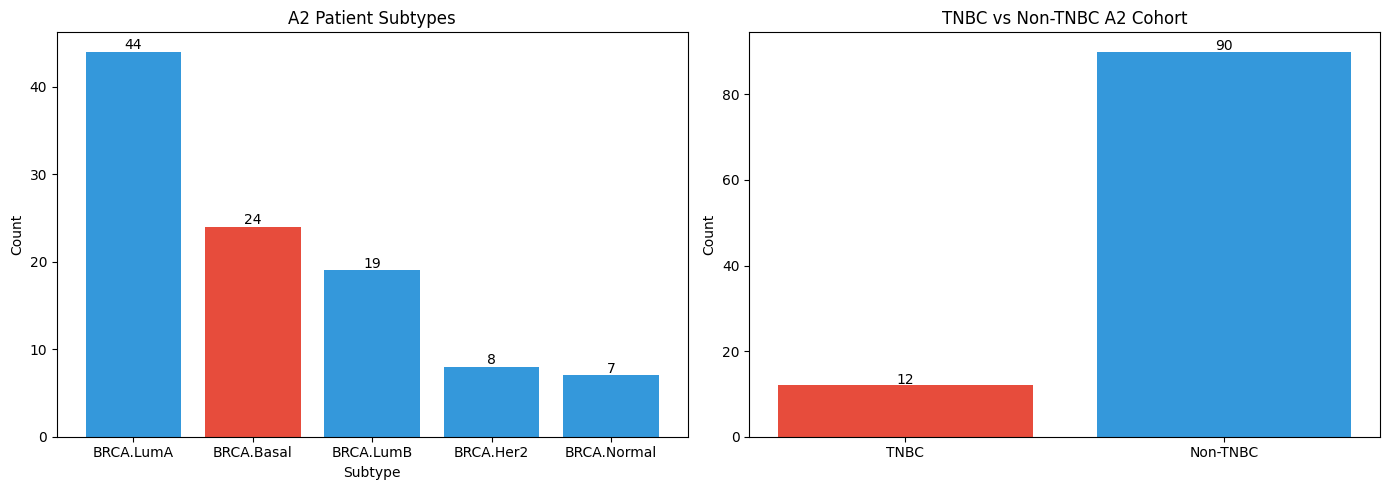

Saved patient_distribution.png


In [86]:
# 18. subtype plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = clini_matched['TCGA Subtype'].value_counts().index.tolist()
counts = clini_matched['TCGA Subtype'].value_counts().values.tolist()
colors = ['#e74c3c' if 'Basal' in l else '#3498db' for l in labels]

axes[0].bar(labels, counts, color=colors)
axes[0].set_title('A2 Patient Subtypes')
axes[0].set_xlabel('Subtype')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.3, str(v), ha='center')

tnbc_counts = [clini_matched['TNBC'].sum(), (clini_matched['TNBC'] == 0).sum()]
axes[1].bar(['TNBC', 'Non-TNBC'], tnbc_counts, color=['#e74c3c', '#3498db'])
axes[1].set_title('TNBC vs Non-TNBC A2 Cohort')
axes[1].set_ylabel('Count')
for i, v in enumerate(tnbc_counts):
    axes[1].text(i, v + 0.3, str(v), ha='center')

plt.tight_layout()
plt.savefig(os.path.join(figures, 'patient_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved patient_distribution.png")

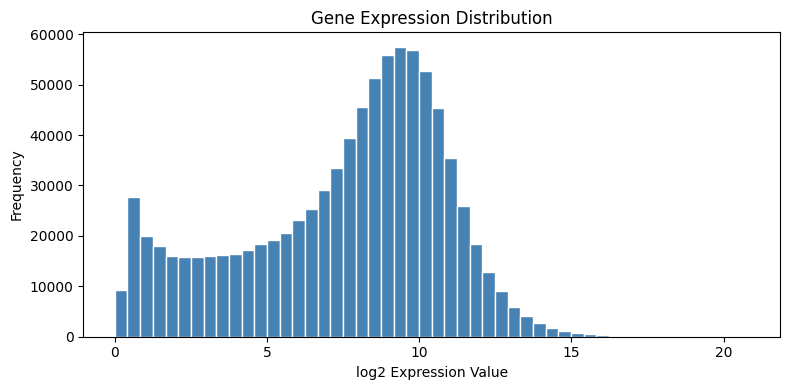

Saved gene_distribution.png


In [87]:
# 19. gene distribution
sample_vals = gene_matched.iloc[:, :50].values.flatten()
sample_vals = sample_vals[sample_vals > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_vals, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Gene Expression Distribution')
ax.set_xlabel('log2 Expression Value')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(os.path.join(figures, 'gene_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved gene_distribution.png")

In [88]:
# 20. notebook 01 complete
print("Notebook 01 complete")
print("A2 images:", len(a2_files))
print("E2 images:", len(e2_files))
print("Matched patients:", len(matched))
print("TNBC patients:", len(tnbc_ids))
print("Gene matrix:", gene_matched.shape)
print("GEO datasets loaded: 3")
print("E2 set aside for external validation only")
print("Results saved to:", processed)

Notebook 01 complete
A2 images: 268938
E2 images: 41061
Matched patients: 102
TNBC patients: 12
Gene matrix: (20530, 102)
GEO datasets loaded: 3
E2 set aside for external validation only
Results saved to: /content/drive/MyDrive/ONCO-PROBE/results_v2/processed


In [62]:
# 21. extract breakhis to drive fresh
import zipfile

zip_breakhis = os.path.join(data, 'BreakHis.zip')
extract_breakhis = os.path.join(data, 'breakhis')

os.makedirs(extract_breakhis, exist_ok=True)
print("Extracting BreakHis")
with zipfile.ZipFile(zip_breakhis, 'r') as z:
    z.extractall(extract_breakhis)

print("BreakHis extraction complete")

Extracting BreakHis
BreakHis extraction complete


In [63]:
# 21b. define breakhis path
extract_breakhis = os.path.join(data, 'breakhis')
print("BreakHis path:", extract_breakhis)
print("Exists:", os.path.exists(extract_breakhis))

BreakHis path: /content/drive/MyDrive/ONCO-PROBE/data/breakhis
Exists: True


In [64]:
# 22. count BreakHis images
breakhis_files = []
for root, dirs, files in os.walk(extract_breakhis):
    for f in files:
        if f.endswith('.jpg') or f.endswith('.png'):
            breakhis_files.append(os.path.join(root, f))

print("BreakHis images:", len(breakhis_files))
print("Example:", breakhis_files[0])

BreakHis images: 7909
Example: /content/drive/MyDrive/ONCO-PROBE/data/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign/SOB/adenosis/SOB_B_A_14-22549AB/100X/SOB_B_A-14-22549AB-100-001.png


In [65]:
# 23. BreakHis labels from folder structure
breakhis_records = []
for path in breakhis_files:
    parts = path.split(os.sep)
    label = None
    for part in parts:
        if part.lower() == 'malignant':
            label = 1
            break
        elif part.lower() == 'benign':
            label = 0
            break
    if label is not None:
        breakhis_records.append({'path': path, 'label': label})

breakhis_df = pd.DataFrame(breakhis_records)
print("BreakHis dataframe:", breakhis_df.shape)
print("Malignant:", (breakhis_df['label'] == 1).sum())
print("Benign:", (breakhis_df['label'] == 0).sum())

BreakHis dataframe: (7909, 2)
Malignant: 5429
Benign: 2480


# diagnostic. check gene ID formats

In [66]:
print("TCGA gene index sample:")
print(gene_matched.index[:10].tolist())
print()
print("GSE76124 index sample:")
print(gse76124.index[:10].tolist())
print()
print("GSE58812 index sample:")
print(gse58812.index[:10].tolist())
print()
print("GSE103091 index sample:")
print(gse103091.index[:10].tolist())

TCGA gene index sample:
['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11', 'RNF13', 'GTF2IP1', 'REM1', 'MTVR2', 'RTN4RL2']

GSE76124 index sample:
['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at', '1316_at', '1320_at', '1405_i_at', '1431_at']

GSE58812 index sample:
['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at', '1316_at', '1320_at', '1405_i_at', '1431_at']

GSE103091 index sample:
['1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at', '1316_at', '1320_at', '1405_i_at', '1431_at']


In [67]:
# 24. use biomart for probe mapping
!pip install pybiomart

from pybiomart import Dataset

print("Connecting to Ensembl BioMart")
dataset = Dataset(name='hsapiens_gene_ensembl',
                  host='http://www.ensembl.org')

probe_map = dataset.query(attributes=['affy_hg_u133_plus_2', 'hgnc_symbol'])
probe_map = probe_map.dropna()
probe_map.columns = ['probe_id', 'gene_symbol']
probe_map = probe_map[probe_map['gene_symbol'] != '']

probe_to_gene = dict(zip(probe_map['probe_id'], probe_map['gene_symbol']))

print("Probe mappings found:", len(probe_to_gene))
print("Example:")
for k, v in list(probe_to_gene.items())[:5]:
    print(k, "->", v)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.9 MB/s eta 0:00:00
Connecting to Ensembl BioMart
Probe mappings found: 41112
Example:
1553551_s_at -> MT-ND2
1553570_x_at -> MT-CO2
1553569_at -> MT-CO2
1553538_s_at -> MTCO1P12
1553567_s_at -> MTATP6P1


In [68]:
# 25. convert GEO probe IDs to gene names
def convert_probes_to_genes(df, probe_map):
    df = df.copy()
    df.index = df.index.map(lambda x: probe_map.get(str(x), None))
    df = df[df.index.notna()]
    df = df[~df.index.duplicated(keep='first')]
    return df

gse76124_genes = convert_probes_to_genes(gse76124, probe_to_gene)
gse58812_genes = convert_probes_to_genes(gse58812, probe_to_gene)
gse103091_genes = convert_probes_to_genes(gse103091, probe_to_gene)

print("GSE76124 after mapping:", gse76124_genes.shape)
print("GSE58812 after mapping:", gse58812_genes.shape)
print("GSE103091 after mapping:", gse103091_genes.shape)
print()
print("GSE76124 gene index sample:", gse76124_genes.index[:5].tolist())

GSE76124 after mapping: (20710, 198)
GSE58812 after mapping: (20710, 107)
GSE103091 after mapping: (20710, 238)

GSE76124 gene index sample: ['DDR1', 'RFC2', 'HSPA7', 'PAX8', 'GUCA1A']


In [69]:
# 26. find common genes
tcga_genes = set(gene_matched.index.tolist())
gse76124_g = set(gse76124_genes.index.tolist())
gse58812_g = set(gse58812_genes.index.tolist())
gse103091_g = set(gse103091_genes.index.tolist())

common_genes = tcga_genes.intersection(gse76124_g).intersection(gse58812_g).intersection(gse103091_g)
print("Common genes after mapping:", len(common_genes))

Common genes after mapping: 15410


In [70]:
# 27. merge on common genes
tcga_common = gene_matched.loc[list(common_genes)]
gse76124_common = gse76124_genes.loc[list(common_genes)]
gse58812_common = gse58812_genes.loc[list(common_genes)]
gse103091_common = gse103091_genes.loc[list(common_genes)]

gene_combined_raw = pd.concat([
    tcga_common,
    gse76124_common,
    gse58812_common,
    gse103091_common
], axis=1)

gene_combined_raw = gene_combined_raw.fillna(0)
gene_combined_raw = gene_combined_raw.replace([np.inf, -np.inf], 0)

batch_labels = (
    ['TCGA'] * tcga_common.shape[1] +
    ['GSE76124'] * gse76124_common.shape[1] +
    ['GSE58812'] * gse58812_common.shape[1] +
    ['GSE103091'] * gse103091_common.shape[1]
)

print("Raw combined shape:", gene_combined_raw.shape)
print("Batches:", pd.Series(batch_labels).value_counts().to_dict())

Raw combined shape: (15410, 645)
Batches: {'GSE103091': 238, 'GSE76124': 198, 'GSE58812': 107, 'TCGA': 102}


In [71]:
# 28. combat batch correction
!pip install inmoose
from inmoose.pycombat import pycombat_norm

print("Applying ComBat batch correction")
gene_combined = pycombat_norm(gene_combined_raw, batch_labels)

print("ComBat correction applied")
print("Corrected gene matrix:", gene_combined.shape)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 11.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.3 MB/s eta 0:00:00
  Created wheel for inmoose: filename=inmoose-0.9.1-cp312-cp312-linux_x86_64.whl size=4985922 sha256=03c89cbdb06ff447594970c8f460a2f38784d728d95a494695171fa64fa3c435
  Stored in directory: /root/.cache/pip/wheels/5c/75/20/cf8b0c3172ffd1761bcb9c1e68648b42d5a01cb665cc4131b8
Successfully built inmoose
Applying ComBat batch correction
ComBat correction applied
Corrected gene matrix: (15410

In [72]:
# 29. save all gene files
gene_combined.to_csv(os.path.join(processed, 'gene_combined_combat.csv'))
gse76124_genes.to_csv(os.path.join(processed, 'gse76124_mapped.csv'))
gse58812_genes.to_csv(os.path.join(processed, 'gse58812_mapped.csv'))
gse103091_genes.to_csv(os.path.join(processed, 'gse103091_mapped.csv'))

print("Saved all mapped and corrected gene files")
print("Final gene matrix:", gene_combined.shape)

Saved all mapped and corrected gene files
Final gene matrix: (15410, 645)


In [73]:
# 30. TNBC gene subset
gene_tnbc = gene_matched[tnbc_ids] if len(tnbc_ids) > 0 else None

if gene_tnbc is not None:
    gene_tnbc.to_csv(os.path.join(processed, 'gene_tnbc.csv'))
    print("TNBC gene matrix:", gene_tnbc.shape)
else:
    print("No TNBC patients found")

TNBC gene matrix: (20530, 12)


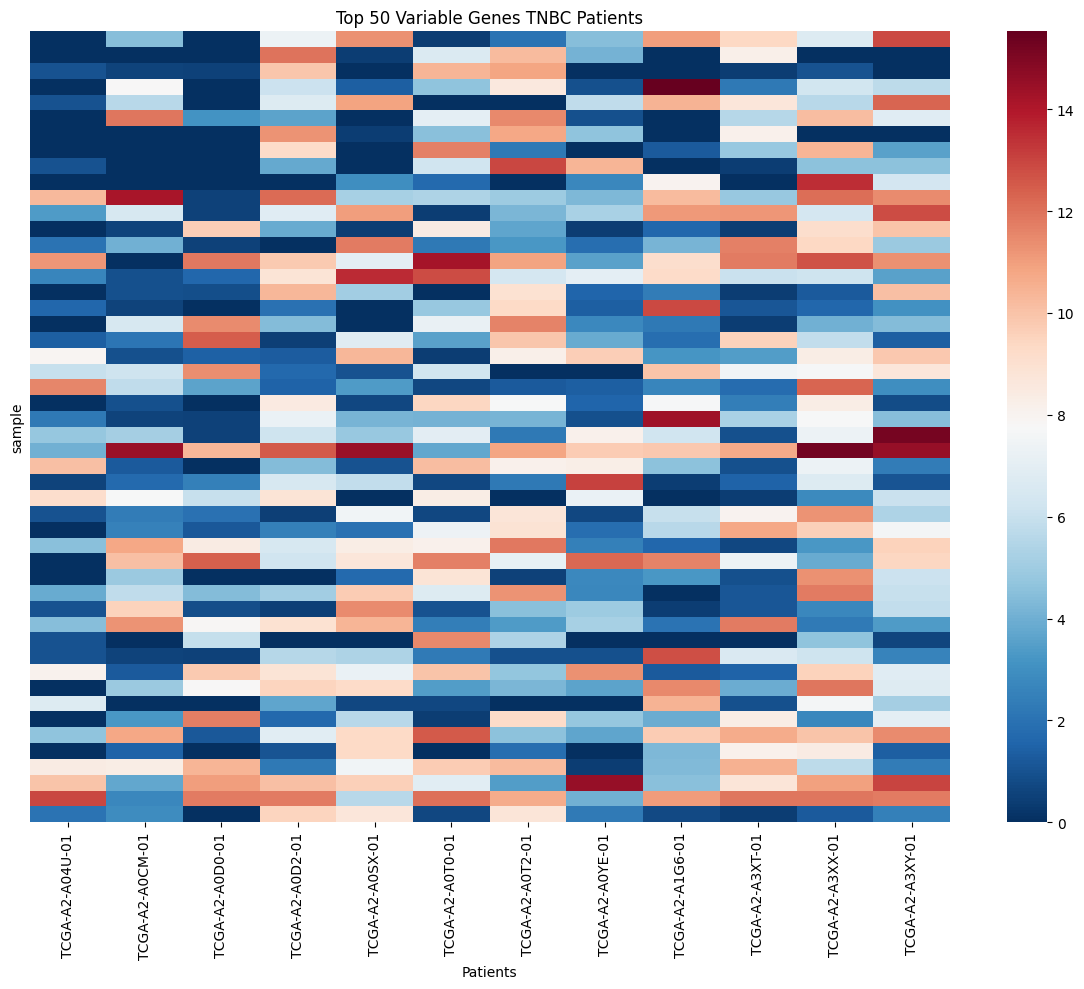

Saved tnbc_gene_heatmap.png


In [74]:
# 31. TNBC gene heatmap
import seaborn as sns

if gene_tnbc is not None:
    top_var_genes = gene_tnbc.var(axis=1).nlargest(50).index
    heatmap_data = gene_tnbc.loc[top_var_genes]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(heatmap_data, cmap='RdBu_r', ax=ax,
                xticklabels=True, yticklabels=False)
    ax.set_title('Top 50 Variable Genes TNBC Patients')
    ax.set_xlabel('Patients')

    plt.tight_layout()
    plt.savefig(os.path.join(figures, 'tnbc_gene_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved tnbc_gene_heatmap.png")

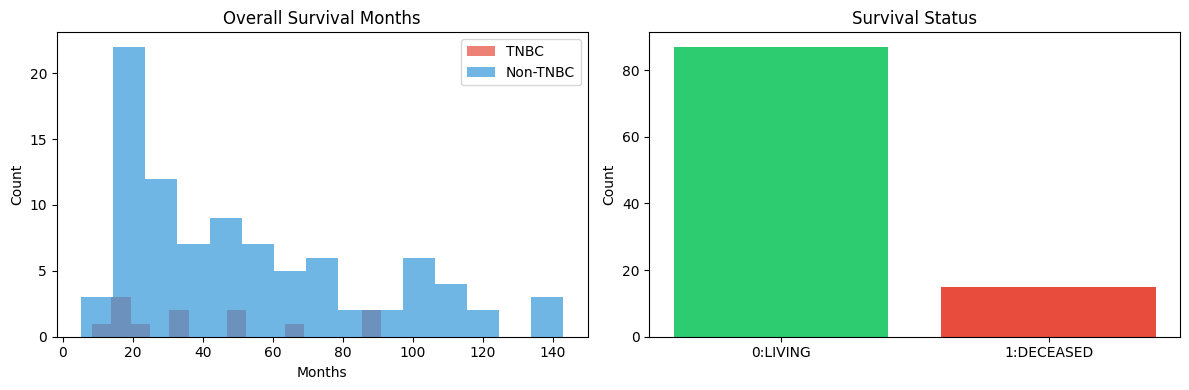

Saved survival_summary.png


In [75]:
# 32. survival summary
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tnbc_surv = clini_matched[clini_matched['TNBC'] == 1]['Overall Survival (Months)'].dropna()
non_surv = clini_matched[clini_matched['TNBC'] == 0]['Overall Survival (Months)'].dropna()

axes[0].hist(tnbc_surv, bins=15, color='#e74c3c', alpha=0.7, label='TNBC')
axes[0].hist(non_surv, bins=15, color='#3498db', alpha=0.7, label='Non-TNBC')
axes[0].set_title('Overall Survival Months')
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Count')
axes[0].legend()

status = clini_matched['Overall Survival Status'].value_counts()
axes[1].bar(status.index, status.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Survival Status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(figures, 'survival_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved survival_summary.png")

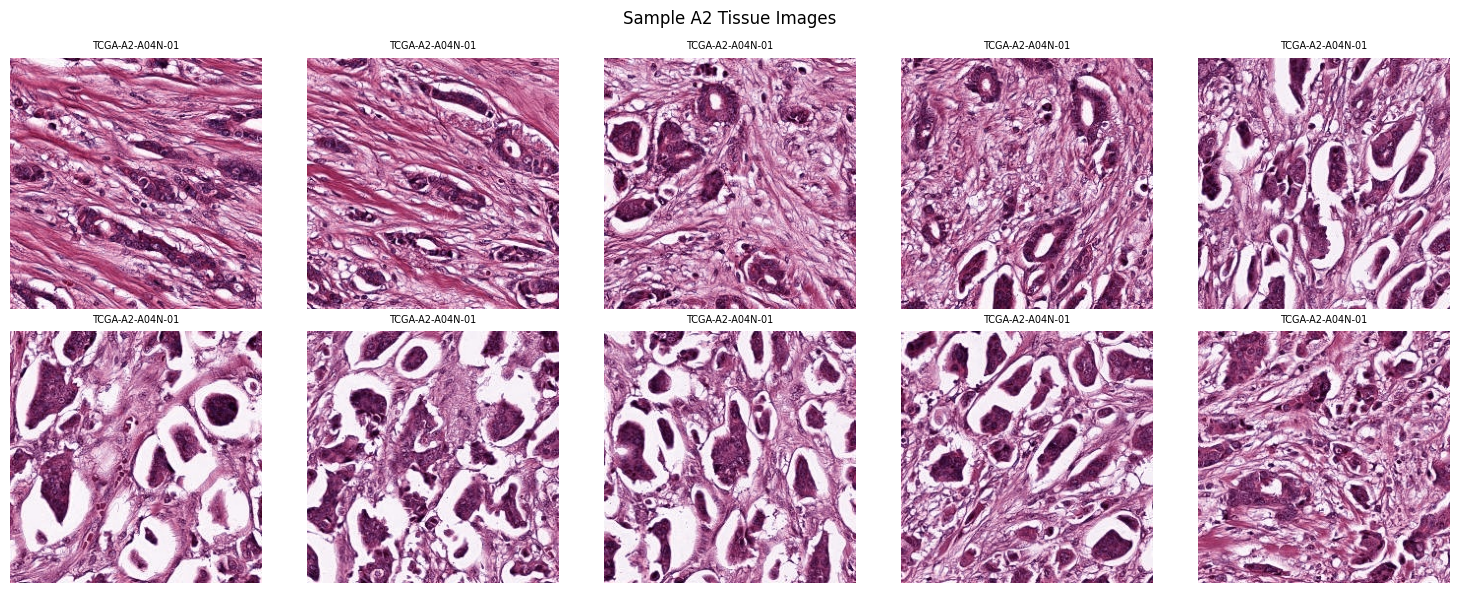

Saved sample_images_a2.png


In [76]:
# 33. sample images
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample A2 Tissue Images')

sample_imgs = a2_files[:10]
for i, ax in enumerate(axes.flatten()):
    img = Image.open(sample_imgs[i])
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(os.path.basename(sample_imgs[i])[:15], fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(figures, 'sample_images_a2.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved sample_images_a2.png")

In [77]:
# 34. notebook 01 complete
print("Notebook 01 complete")
print()
print("A2 images:", len(a2_files))
print("E2 images:", len(e2_files))
print("BreakHis images:", len(breakhis_files))
print("Matched gene patients:", len(matched))
print("TNBC patients A2:", len(tnbc_ids))
print("Gene combined matrix:", gene_combined.shape)
print("GEO datasets merged and corrected")
print()
print("E2 untouched for external validation")
print("Figures saved:", figures)
print("Data saved:", processed)

Notebook 01 complete

A2 images: 268938
E2 images: 41061
BreakHis images: 7909
Matched gene patients: 102
TNBC patients A2: 12
Gene combined matrix: (15410, 645)
GEO datasets merged and corrected

E2 untouched for external validation
Figures saved: /content/drive/MyDrive/ONCO-PROBE/results_v2/figures
Data saved: /content/drive/MyDrive/ONCO-PROBE/results_v2/processed


In [78]:
# 35. check GEO TNBC labels
import gzip

def extract_geo_metadata(filename):
    path = os.path.join(data, filename)
    metadata = []
    with gzip.open(path, 'rt') as f:
        for line in f:
            if line.startswith('!Sample_title') or \
               line.startswith('!Sample_characteristics') or \
               line.startswith('!Sample_geo_accession'):
                metadata.append(line.strip())
    return metadata

print("GSE76124 metadata sample:")
meta76 = extract_geo_metadata('GSE76124_series_matrix.txt.gz')
for line in meta76[:10]:
    print(line[:150])

GSE76124 metadata sample:
!Sample_title	"S1-H10"	"S1-H14"	"S1-H19"	"S1-H20B"	"S1-H22"	"S1-H27"	"S1-H28"	"S1-H29"	"S1-H2B"	"S1-H31"	"S1-H35B"	"S1-H36"	"S1-H38"	"S1-H3B"	"S1-H40"
!Sample_geo_accession	"GSM1974566"	"GSM1974567"	"GSM1974568"	"GSM1974569"	"GSM1974570"	"GSM1974571"	"GSM1974572"	"GSM1974573"	"GSM1974574"	"GSM1974575
!Sample_characteristics_ch1	"tissue: Breast cancer"	"tissue: Breast cancer"	"tissue: Breast cancer"	"tissue: Breast cancer"	"tissue: Breast cancer"	"t
!Sample_characteristics_ch1	"gender: Female"	"age (years): 41"	"age (years): 55"	"age (years): 55"	"age (years): 65"	"age (years): 40"	"age (years): 6
!Sample_characteristics_ch1	"race: Caucasian"	"gender: Female"	"gender: Female"	"gender: Female"	"gender: Female"	"gender: Female"	"gender: Female"	"g
!Sample_characteristics_ch1	"body mass index: 32"	"race: Caucasian"	"race: Caucasian"	"race: Caucasian"	"race: Caucasian"	"race: Caucasian"	"race: Cau
!Sample_characteristics_ch1	"menopausal status: Post-Menopausal"	"bo

In [79]:
# 36. check GSE58812 metadata
print("GSE58812 metadata sample:")
meta58 = extract_geo_metadata('GSE58812_series_matrix.txt.gz')
for line in meta58[:10]:
    print(line[:150])

GSE58812 metadata sample:
!Sample_title	"GP_001"	"GP_002"	"GP_003"	"GP_004"	"GP_005"	"GP_006"	"GP_007"	"GP_008"	"GP_009"	"GP_010"	"GP_011"	"GP_012"	"GP_013"	"GP_014"	"GP_015"	"
!Sample_geo_accession	"GSM1419942"	"GSM1419943"	"GSM1419944"	"GSM1419945"	"GSM1419946"	"GSM1419947"	"GSM1419948"	"GSM1419949"	"GSM1419950"	"GSM1419951
!Sample_characteristics_ch1	"diagnosis: triple negative breast cancer"	"diagnosis: triple negative breast cancer"	"diagnosis: triple negative breast c
!Sample_characteristics_ch1	"age at diag: 72.79124"	"age at diag: 66.26421"	"age at diag: 67.75633"	"age at diag: 49.54963"	"age at diag: 84.63245"	"a
!Sample_characteristics_ch1	"meta: 1"	"meta: 1"	"meta: 1"	"meta: 1"	"meta: 1"	"meta: 0"	"meta: 0"	"meta: 0"	"meta: 1"	"meta: 0"	"meta: 0"	"meta: 1"	"m
!Sample_characteristics_ch1	"mfs (days): 1184"	"mfs (days): 984"	"mfs (days): 877"	"mfs (days): 905"	"mfs (days): 340"	"mfs (days): 2081"	"mfs (days):
!Sample_characteristics_ch1	"death: 1"	"death: 1"	"death: 1"	"death:

In [80]:
# 37. check GSE103091 metadata
print("GSE103091 metadata sample:")
meta103 = extract_geo_metadata('GSE103091_series_matrix.txt.gz')
for line in meta103[:10]:
    print(line[:150])

GSE103091 metadata sample:
!Sample_title	"GP_001"	"GP_002"	"GP_003"	"GP_004"	"GP_005"	"GP_006"	"GP_007"	"GP_008"	"GP_009"	"GP_010"	"GP_011"	"GP_012"	"GP_013"	"GP_014"	"GP_015"	"
!Sample_geo_accession	"GSM1419942"	"GSM1419943"	"GSM1419944"	"GSM1419945"	"GSM1419946"	"GSM1419947"	"GSM1419948"	"GSM1419949"	"GSM1419950"	"GSM1419951
!Sample_characteristics_ch1	"diagnosis: triple negative breast cancer"	"diagnosis: triple negative breast cancer"	"diagnosis: triple negative breast c
!Sample_characteristics_ch1	"age at diag: 72.79124"	"age at diag: 66.26421"	"age at diag: 67.75633"	"age at diag: 49.54963"	"age at diag: 84.63245"	"a
!Sample_characteristics_ch1	"meta: 1"	"meta: 1"	"meta: 1"	"meta: 1"	"meta: 1"	"meta: 0"	"meta: 0"	"meta: 0"	"meta: 1"	"meta: 0"	"meta: 0"	"meta: 1"	"m
!Sample_characteristics_ch1	"mfs (days): 1184"	"mfs (days): 984"	"mfs (days): 877"	"mfs (days): 905"	"mfs (days): 340"	"mfs (days): 2081"	"mfs (days):
!Sample_characteristics_ch1	"death: 1"	"death: 1"	"death: 1"	"death

In [81]:
# 38. extract TNBC labels from GEO datasets
import gzip

def extract_geo_sample_labels(filename):
    path = os.path.join(data, filename)
    sample_ids = []
    characteristics = []

    with gzip.open(path, 'rt') as f:
        for line in f:
            if line.startswith('!Sample_geo_accession'):
                ids = line.strip().split('\t')[1:]
                sample_ids = [x.strip().strip('"') for x in ids]
            if line.startswith('!Sample_characteristics_ch1'):
                chars = line.strip().split('\t')[1:]
                chars = [x.strip().strip('"') for x in chars]
                characteristics.append(chars)

    return sample_ids, characteristics

# GSE58812 — all TNBC
ids58, chars58 = extract_geo_sample_labels('GSE58812_series_matrix.txt.gz')
labels_58 = {sid: 1 for sid in ids58}
print("GSE58812 samples:", len(labels_58))
print("All TNBC: yes — diagnosis field confirms")

# GSE103091 — all TNBC
ids103, chars103 = extract_geo_sample_labels('GSE103091_series_matrix.txt.gz')
labels_103 = {sid: 1 for sid in ids103}
print("GSE103091 samples:", len(labels_103))
print("All TNBC: yes — diagnosis field confirms")

# GSE76124 — need to check TN field
ids76, chars76 = extract_geo_sample_labels('GSE76124_series_matrix.txt.gz')
print("GSE76124 samples:", len(ids76))
print("Need to check which are TNBC")

GSE58812 samples: 107
All TNBC: yes — diagnosis field confirms
GSE103091 samples: 238
All TNBC: yes — diagnosis field confirms
GSE76124 samples: 198
Need to check which are TNBC


In [82]:
# 39. extract GSE76124 TNBC labels
labels_76 = {}
for i, sid in enumerate(ids76):
    is_tnbc = False
    for char_row in chars76:
        if i < len(char_row):
            val = char_row[i].lower()
            if 'validation tn' in val or 'triple negative' in val or 'tn' in val:
                is_tnbc = True
                break
    labels_76[sid] = 1 if is_tnbc else 0

tnbc_76 = sum(1 for v in labels_76.values() if v == 1)
print("GSE76124 total:", len(labels_76))
print("GSE76124 TNBC:", tnbc_76)
print("GSE76124 non-TNBC:", len(labels_76) - tnbc_76)

GSE76124 total: 198
GSE76124 TNBC: 198
GSE76124 non-TNBC: 0


**fix all missing variables for cell 40**

In [131]:
# fix all missing variables for cell 40
import gzip
import pandas as pd
import numpy as np

# reload clini
clini = pd.read_csv(os.path.join(processed, 'clinical_a2_matched.csv'))

# reload gene combined
gene_combined = pd.read_csv(os.path.join(processed, 'gene_combined_combat.csv'), index_col=0)

# reload GEO labels
def extract_geo_sample_labels(filename):
    path = os.path.join(data, filename)
    sample_ids = []
    characteristics = []
    with gzip.open(path, 'rt') as f:
        for line in f:
            if line.startswith('!Sample_geo_accession'):
                ids = line.strip().split('\t')[1:]
                sample_ids = [x.strip().strip('"') for x in ids]
            if line.startswith('!Sample_characteristics_ch1'):
                chars = line.strip().split('\t')[1:]
                chars = [x.strip().strip('"') for x in chars]
                characteristics.append(chars)
    return sample_ids, characteristics

ids58, chars58 = extract_geo_sample_labels('GSE58812_series_matrix.txt.gz')
labels_58 = {sid: 1 for sid in ids58}

ids103, chars103 = extract_geo_sample_labels('GSE103091_series_matrix.txt.gz')
labels_103 = {sid: 1 for sid in ids103}

ids76, chars76 = extract_geo_sample_labels('GSE76124_series_matrix.txt.gz')
labels_76 = {}
for i, sid in enumerate(ids76):
    is_tnbc = False
    for char_row in chars76:
        if i < len(char_row):
            val = char_row[i].lower()
            if 'validation tn' in val or 'triple negative' in val or 'tn' in val:
                is_tnbc = True
                break
    labels_76[sid] = 1 if is_tnbc else 0

print("clini:", clini.shape)
print("gene_combined:", gene_combined.shape)
print("GEO labels loaded")
print("GSE58812:", len(labels_58))
print("GSE103091:", len(labels_103))
print("GSE76124:", len(labels_76))

clini: (102, 204)
gene_combined: (15410, 645)
GEO labels loaded
GSE58812: 107
GSE103091: 238
GSE76124: 198


In [134]:
# 40. build full gene label dictionary
all_gene_labels = {}

clini_indexed = clini.set_index('Sample ID')
for sid in clini_indexed.index:
    if sid in gene_combined.columns:
        all_gene_labels[sid] = int(clini_indexed.loc[sid, 'TNBC'])

for sid, label in labels_58.items():
    all_gene_labels[sid] = label

for sid, label in labels_103.items():
    all_gene_labels[sid] = label

for sid, label in labels_76.items():
    all_gene_labels[sid] = label

total_tnbc = sum(1 for v in all_gene_labels.values() if v == 1)
total_non = sum(1 for v in all_gene_labels.values() if v == 0)

print("Total labeled patients:", len(all_gene_labels))
print("Total TNBC:", total_tnbc)
print("Total non-TNBC:", total_non)

Total labeled patients: 538
Total TNBC: 448
Total non-TNBC: 90


In [135]:
# 41. match labels to combined gene matrix
gene_labels_df = pd.DataFrame({
    'sample_id': list(all_gene_labels.keys()),
    'TNBC': list(all_gene_labels.values())
})

available = [sid for sid in gene_combined.columns if sid in all_gene_labels]
gene_labeled = gene_combined[available]
labels_matched = [all_gene_labels[sid] for sid in available]

print("Gene matrix patients with labels:", len(available))
print("TNBC:", sum(labels_matched))
print("Non-TNBC:", len(labels_matched) - sum(labels_matched))

gene_labels_df.to_csv(os.path.join(processed, 'gene_labels_all.csv'), index=False)
gene_labeled.to_csv(os.path.join(processed, 'gene_labeled.csv'))
print("Saved gene_labels_all.csv and gene_labeled.csv")

Gene matrix patients with labels: 538
TNBC: 448
Non-TNBC: 90
Saved gene_labels_all.csv and gene_labeled.csv


In [136]:
# 42. final summary with gene labels
print("Notebook 01 fully complete")
print()
print("A2 images:", len(a2_files))
print("E2 images:", len(e2_files))
print("BreakHis images:", len(breakhis_files))
print("TNBC image patients A2:", len(tnbc_ids))
print("Gene combined matrix:", gene_combined.shape)
print("Gene labeled patients:", len(available))
print("TNBC in gene data:", sum(labels_matched))
print("Non-TNBC in gene data:", len(labels_matched) - sum(labels_matched))
print()
print("All saved to results_v2/processed/")

Notebook 01 fully complete

A2 images: 268938
E2 images: 41061
BreakHis images: 7909
TNBC image patients A2: 12
Gene combined matrix: (15410, 645)
Gene labeled patients: 538
TNBC in gene data: 448
Non-TNBC in gene data: 90

All saved to results_v2/processed/
